In [3]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Arvind\Downloads\Sample data for project\Netflix-Data-Analysis.csv")

df.head()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [4]:
# Step 1: Check Missing Values:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [5]:
# Step 2: Clean Missing Values:

df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

df['date_added'] = df['date_added'].fillna('Not Available')
df['duration'] = df['duration'].fillna('Unknown')

In [6]:
# Step 3: Check Again:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [7]:
# Step 4: Check for Duplicates

df.duplicated().sum()

np.int64(0)

In [8]:
# Step 5: Start Analysis:
df['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

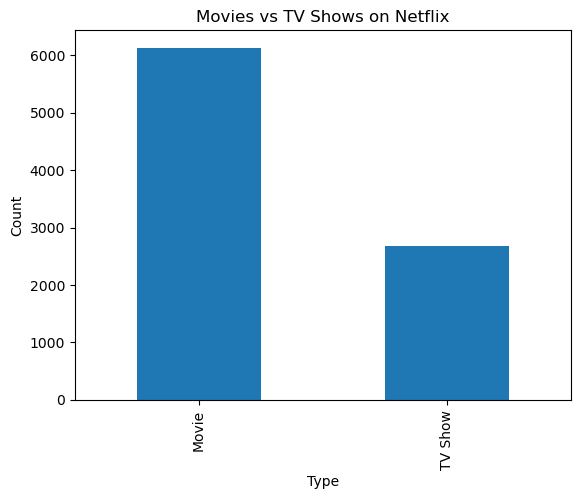

In [9]:
import matplotlib.pyplot as plt

df['type'].value_counts().plot(kind='bar')

plt.title('Movies vs TV Shows on Netflix')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

In [10]:
# Next Analysis: Top 10 Countries:

all_genres = df['listed_in'].str.split(', ').explode()

top_genres = all_genres.value_counts().head(10)

top_genres

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

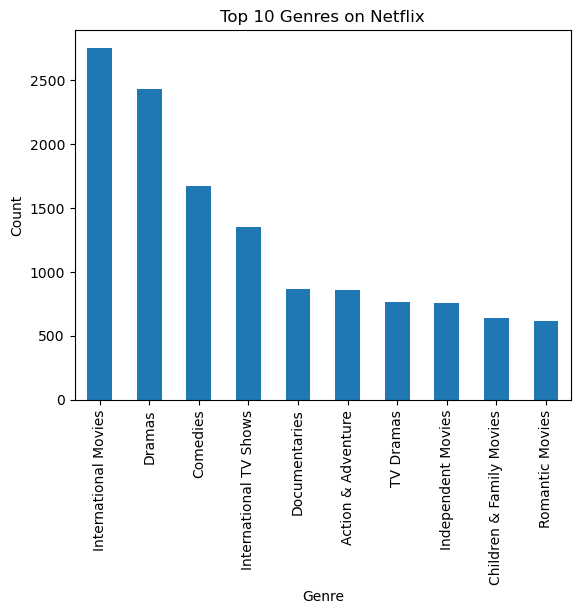

In [11]:
# Create chart:

top_genres.plot(kind='bar')

plt.title('Top 10 Genres on Netflix')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.show()

In [12]:
# Next Analysis: Content Added Over Years:

df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

df['year_added'] = df['date_added'].dt.year

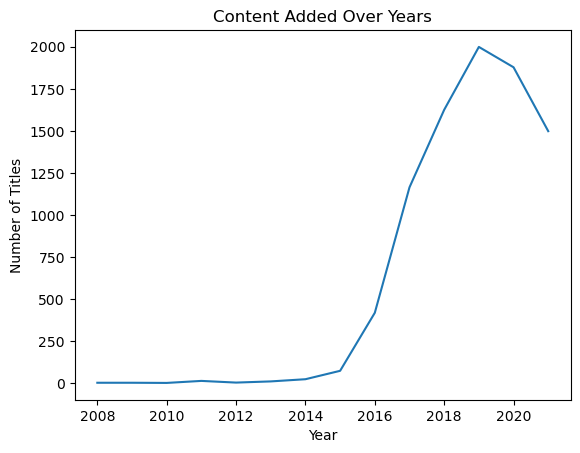

In [13]:
# Chart

df['year_added'].value_counts().sort_index().plot()

plt.title('Content Added Over Years')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.show()

In [14]:
# Final Analysis: Movie Duration

movies = df[df['type'] == 'Movie'].copy()

movies['duration'] = movies['duration'].str.replace(' min', '', regex=False)
movies['duration'] = pd.to_numeric(movies['duration'], errors='coerce')

movies['duration'].describe()

count    6128.000000
mean       99.577187
std        28.290593
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration, dtype: float64

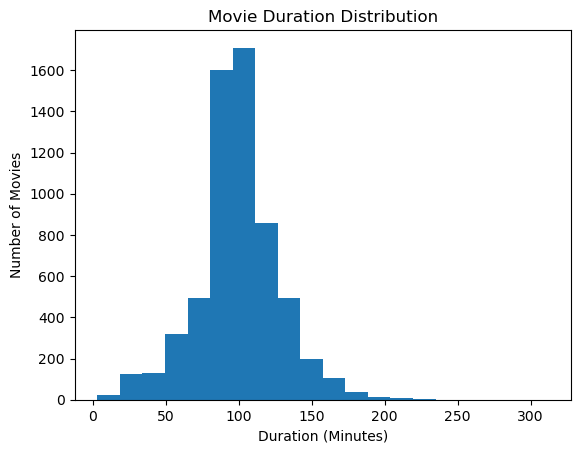

In [15]:
# chart:

import matplotlib.pyplot as plt

plt.hist(movies['duration'].dropna(), bins=20)

plt.title('Movie Duration Distribution')
plt.xlabel('Duration (Minutes)')
plt.ylabel('Number of Movies')
plt.show()

# Final Project Insights Section
## Key Insights

1. Movies significantly outnumber TV Shows on Netflix.
2. International Movies and Dramas are the most common genres.
3. The United States contributes the largest number of Netflix titles.
4. Netflix expanded rapidly between 2015 and 2020.
5. Most movies have durations between 80 and 120 minutes.
6. International content represents a major portion of Netflix's library.

# Netflix Data Analysis

## Project Overview
This project analyzes Netflix Movies and TV Shows data using Python. The objective is to explore content trends, genre popularity, country contributions, and content growth over time.

## Tools Used
- Python
- Pandas
- NumPy
- Matplotlib

## Analysis Performed
- Data Cleaning
- Missing Value Handling
- Duplicate Detection
- Movies vs TV Shows Analysis
- Country Analysis
- Genre Analysis
- Content Added Over Time
- Movie Duration Analysis

## Key Findings
- Movies dominate Netflix's content library.
- International Movies and Dramas are highly represented.
- The United States contributes the most titles.
- Netflix experienced significant content growth after 2015.

## Dataset
Netflix Movies and TV Shows Dataset from Kaggle.